In [2]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import networkx as nx
from sklearn import metrics
from matplotlib import gridspec


import seaborn as sns
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

#import tensorflow as tf 
import tensorboard as tb 
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
from matplotlib import dates
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']

from my_funs_nei import *
q = [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]


/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [24]:
def prediction_plot_output(training, tft ,data, dong , title, ewma_funs, factor , output_sel):
    df = data[data['h_dong']==dong]
    df_index = df[df['time_idx'] > 24* 7 -1]['REG_DTIME']
    org_data = data_processing('nei_test.csv' , 0 , None)
    org_data = org_data[org_data['h_dong'] == dong]
    org_ewma_data = data_processing('nei_test.csv' , factor , ewma_funs)
    org_ewma_data = org_ewma_data[org_ewma_data['h_dong'] == dong]
    s_size = 4
    
    prediction_df = pd.DataFrame()
    for file in sorted(os.listdir('./test_data'))[1:]:
        val_data = data_processing('./test_data/' + file , factor , ewma_funs)
        val_data = val_data.fillna(0)
        validation = TimeSeriesDataSet.from_dataset(training, val_data, predict=True, stop_randomization=True)
        val_dataloader = validation.to_dataloader(train=False, batch_size=16, num_workers=0)
        pred , x, idx_df = tft.predict(val_dataloader, mode='raw', return_x = True , return_index = True)
        idx = idx_df[idx_df['h_dong'] == dong].index[0]
        
        xyz = pd.DataFrame()
        delta_h = val_data['REG_DTIME'].unique()[1] - val_data['REG_DTIME'].unique()[0] 
        s = val_data['REG_DTIME'].unique().max() + delta_h
        e = val_data['REG_DTIME'].unique().max() + 24*delta_h

        #print(pd.date_range(s,e ,freq = 'h'))
        xyz.index = pd.date_range(s,e ,freq = 'h')
        xyz['prediction50'] = pred['prediction'][output_sel][idx, : , 3]
        xyz['prediction75'] = pred['prediction'][output_sel][idx, : , 4]
        xyz['prediction90'] = pred['prediction'][output_sel][idx, : , 5]
        prediction_df = pd.concat([prediction_df, xyz])

    fig = plt.figure(figsize=(15, 150))
    gs = gridspec.GridSpec(nrows = 25, # row 몇 개 
                       ncols=1, # col 몇 개 
                       height_ratios=np.full(25,1), 
                       width_ratios=[1]
                      )

    gs.update(wspace=0.1, hspace=0.5)
 
    for i in range(25):
        ax = plt.subplot(gs[i,0])
        ax.set_title(f'sex{i}')


        #idx = prediction_df.index[:-24]
        idx = prediction_df.index[i*48:(i+1)*48]
        org_count = org_data[org_data['REG_DTIME'].isin(idx)]['count']    
        org_ewma_count = org_ewma_data[org_ewma_data['REG_DTIME'].isin(idx)]['count']    

        ax.plot(idx ,prediction_df.loc[idx, 'prediction50'] , label = 'preidction 50%' , alpha=0.8)
        ax.plot(idx ,prediction_df.loc[idx, 'prediction75'] , label = 'preidction 75%' , alpha=0.5)
        ax.plot(idx ,prediction_df.loc[idx, 'prediction90'] , label = 'preidction 90%' , alpha=0.3)
        ax.plot(idx ,org_count , label = 'orginal target' , alpha=0.4)
        ax.plot(idx ,org_ewma_count , label = 'ewma apply target' , alpha=0.4)
        ax.xaxis.set_major_locator(dates.HourLocator())
        ax.set_xticklabels(ax.get_xticks(), rotation = 45, fontsize = 8)
        ax.xaxis.set_major_formatter(dates.DateFormatter('%Y-%m-%d %H'))


        ax.set_title(f'{dong}  {idx[0]} ~ {idx[-1]}',fontsize=15)
        ax.legend()


In [25]:
model_ckpt = 'ckpt/lightning_logs/version_1/checkpoints/epoch=299-step=6000.ckpt'
factor = 0.3
funs = moving_average_alpha_both

train_data = data_processing('nei_train.csv' , factor , funs)
test_data = data_processing('nei_test.csv' , factor, funs)
training = get_training(train_data , 24, 24*7)
tft = TemporalFusionTransformer.load_from_checkpoint(model_ckpt)

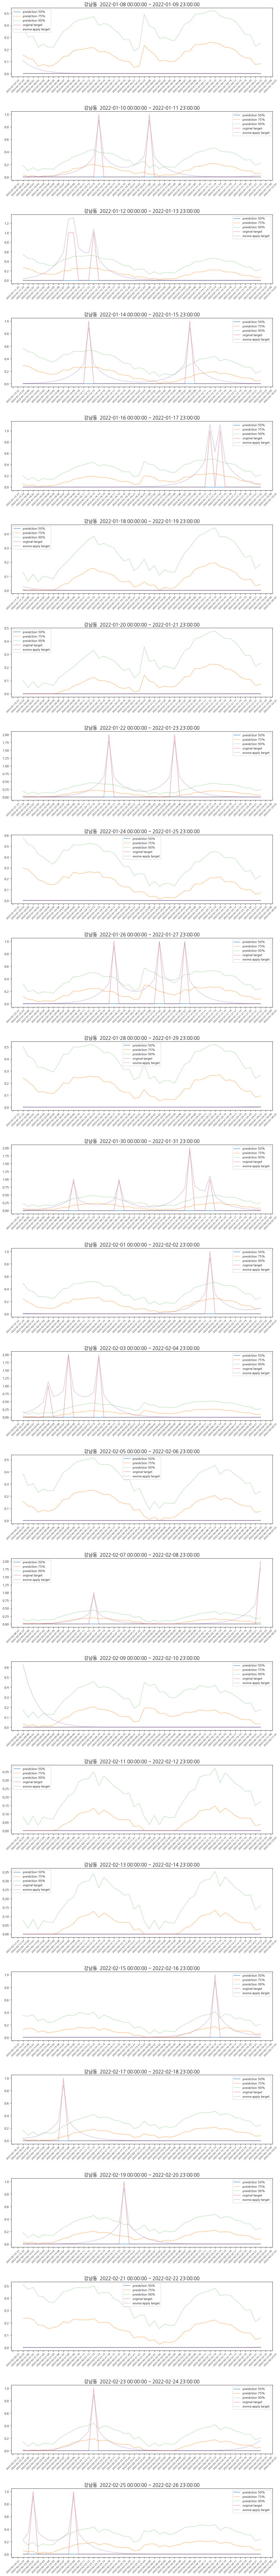

In [26]:
prediction_plot_output(training, tft ,test_data, '강남동' , f'emwa : alpha , factor : {factor}' , funs, factor , 0)

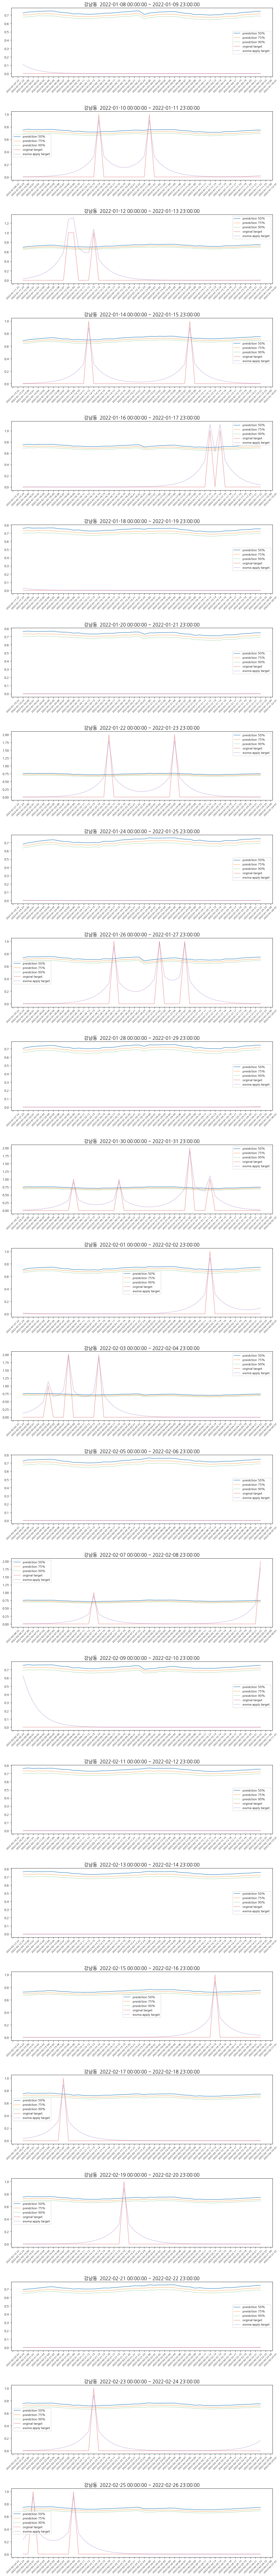

In [27]:
prediction_plot_output(training, tft ,test_data, '강남동' , f'emwa : alpha , factor : {factor}' , funs, factor , 1)